# Cross-layer EDA 05: Biological explanations and route stability

This notebook remains **exploratory data analysis**. It asks two questions before any predictive model is fitted:

1. Can Reactome, STRING, and BioGRID explain a measured gene-pair relationship in understandable biological language?
2. Do CRISPR relationships remain similar when one cancer lineage is removed from the analysis?

The three measured routes from the previous notebook remain distinct:

- direct fusion is a measured transcript joining two genes;
- CRISPR codependency is similarity between two knockout profiles;
- conditional dependency is a directional `Gene A context -> Gene B dependency` hypothesis.

External biological databases are used as **explanation evidence**, not as a hidden score or automatic answer key. The final sections define what an independent validation target would need to contain before a probability model could be trained or calibrated.

## Guardrails

- Use canonical HGNC identifiers to connect genes to explanation databases.
- Keep Reactome, STRING, and BioGRID evidence in separate columns.
- Treat “no database record found” as missing explanation evidence, not proof of no biological relationship.
- Do not treat lineage specificity of a fusion as instability; many cancer drivers are tissue-specific.
- Leave-one-lineage-out analysis is sensitivity EDA, not model validation.
- Keep exact model and lineage denominators.
- Do not fit, rank, weight, or calibrate gene pairs in this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 160)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([str(gene_a).upper(), str(gene_b).upper()]))


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CORE = PROJECT_ROOT / 'data' / 'depmap_24Q4'
EXT = PROJECT_ROOT / 'data' / 'external'
PATHS = {
    'master': CORE / 'architecture' / 'model_master.csv',
    'gene_master': CORE / 'architecture' / 'gene_master.csv',
    'fusion_pairs': CORE / 'architecture' / 'fusion_pair_evidence.csv',
    'effect': CORE / 'raw' / 'CRISPRGeneEffect.csv',
    'mutations': CORE / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'copy_number': CORE / 'raw' / 'OmicsAbsoluteCNGene.csv',
    'reactome': EXT / 'reactome' / 'derived' / 'reactome_gene_pathway.csv',
    'string': EXT / 'string_v12' / 'derived' / 'string_human_high_confidence_edges.csv',
    'biogrid': EXT / 'biogrid' / 'derived' / 'biogrid_human_edges.csv',
    'tcga_clinical': EXT / 'tcga_gdc' / 'derived' / 'tcga_patient_master.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
gene_master = pd.read_csv(PATHS['gene_master'], low_memory=False)
fusion_calls = pd.read_csv(PATHS['fusion_pairs'], low_memory=False)
mutations = pd.read_csv(PATHS['mutations'], low_memory=False)
reactome = pd.read_csv(PATHS['reactome'], low_memory=False)
string_edges = pd.read_csv(PATHS['string'], low_memory=False)
biogrid_edges = pd.read_csv(PATHS['biogrid'], low_memory=False)
tcga_clinical = pd.read_csv(PATHS['tcga_clinical'], low_memory=False)

assert master['model_id'].is_unique
assert gene_master['symbol'].is_unique
master['oncotree_lineage'] = master['oncotree_lineage'].fillna('Unknown')
lineage_lookup = master.set_index('model_id')['oncotree_lineage']

print(f'Identity spine: {len(master):,} cell-line models')
print(f'Reactome gene-pathway rows: {len(reactome):,}')
print(f'High-confidence STRING edges: {len(string_edges):,}')
print(f'BioGRID source-preserving edges: {len(biogrid_edges):,}')
print(f'TCGA clinical patients: {tcga_clinical.patient_id.nunique():,}')

Identity spine: 2,105 cell-line models
Reactome gene-pathway rows: 54,499
High-confidence STRING edges: 230,779
BioGRID source-preserving edges: 963,018
TCGA clinical patients: 11,428


## Column dictionary

| Column | Meaning | Project use |
|---|---|---|
| `pair_id` | Alphabetically ordered pair of gene symbols. | Common reporting key for undirected explanations. |
| `gene_a_id`, `gene_b_id` | Canonical HGNC identifiers from the project gene identity table. | Safe join keys for Reactome, STRING, and BioGRID. |
| `shared_reactome_pathways` | Number of Reactome pathways containing both genes. | Named shared-process explanation. |
| `smallest_shared_pathways` | Shared pathways with the fewest annotated genes. | More specific examples that are often easier to interpret than very broad pathways. |
| `string_direct_edges` | Number of retained high-confidence STRING associations for the exact pair. | Functional-association explanation; not necessarily physical binding. |
| `max_string_score` | Largest STRING combined score for the exact pair. | Source-specific association strength, not a project probability. |
| `biogrid_experimental_systems` | Number of distinct BioGRID experiment types supporting the pair. | Shows how the relationship was experimentally observed. |
| `biogrid_curated_records` | Sum of curated BioGRID records for the pair. | Evidence quantity with source-specific meaning. |
| `explanation_sources_found` | Text list of databases containing pair evidence. | Dashboard explanation availability, not a confidence score. |
| `models_with_direct_fusion` | Cell-line models with the exact retained fusion call. | Direct-fusion numerator. |
| `fusion_lineages` | Lineages containing the exact fusion call. | Shows expected disease-context concentration. |
| `dominant_fusion_lineage_pct` | Percentage of called models in the most frequent lineage. | Describes lineage specificity; high values are not automatically bad. |
| `baseline_adjusted_rho` | Full-cohort lineage-adjusted CRISPR codependency correlation. | Reference value for sensitivity analysis. |
| `held_out_lineage` | Cancer lineage removed from one sensitivity run. | Tests whether one lineage dominates the association. |
| `held_out_adjusted_rho` | Adjusted codependency after removing one lineage. | Route-stability measurement. |
| `direction_retained_pct` | Percentage of leave-one-lineage-out runs with the same sign as the full result. | Directional robustness descriptor; not proof of biology. |
| `directional_pair_id` | Conditional hypothesis in `Gene A -> Gene B` order. | Preserves the biological direction. |
| `context_type` | Damaging mutation or absolute copy-number loss in this notebook. | Keeps conditional mechanisms separate. |
| `baseline_dependency_shift` | Full-cohort lineage-adjusted conditional shift. | Positive means context models are more dependent on Gene B. |
| `held_out_dependency_shift` | Conditional shift after excluding one lineage. | Tests sensitivity to disease composition. |
| `validation_label` | Future externally defined pair outcome. | Must come from an independent assay or curated answer key. |

## 1. Explanation-source integrity and panel coverage

We use the same 15-pair exploratory panel as the previous gene-pair notebook. The first audit checks whether every symbol resolves to one project gene identity and whether the external tables use compatible HGNC identifiers.

,symbol,gene_id,hgnc_id,status,is_protein_coding
0,ABL1,HGNC:76,HGNC:76,Approved,1
1,ALK,HGNC:427,HGNC:427,Approved,1
2,ARID1A,HGNC:11110,HGNC:11110,Approved,1
3,BCR,HGNC:1014,HGNC:1014,Approved,1
4,BRAF,HGNC:1097,HGNC:1097,Approved,1
5,BRCA1,HGNC:1100,HGNC:1100,Approved,1
6,BRCA2,HGNC:1101,HGNC:1101,Approved,1
7,CDK4,HGNC:1773,HGNC:1773,Approved,1
8,EML4,HGNC:1316,HGNC:1316,Approved,1
9,ERG,HGNC:3446,HGNC:3446,Approved,1


,source,panel_genes_resolved,panel_genes_total,coverage_pct
0,Reactome,24,26,92.307692
1,STRING,26,26,100.000000
2,BioGRID,26,26,100.000000


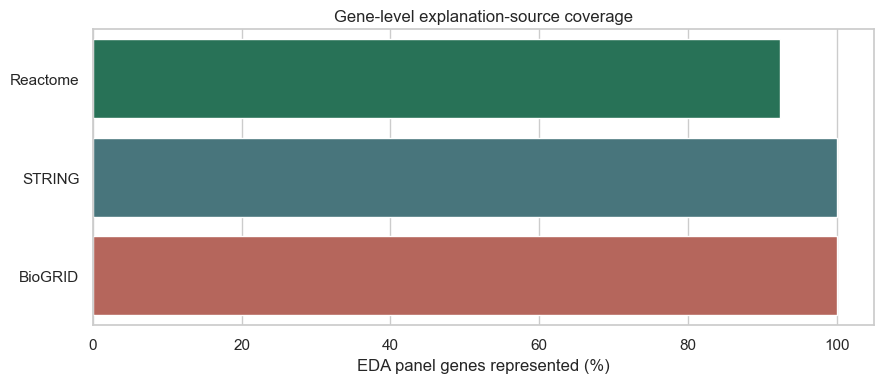

In [2]:
pair_specs = [
    ('BCR', 'ABL1', 'Direct fusion example'),
    ('EML4', 'ALK', 'Direct fusion example'),
    ('TMPRSS2', 'ERG', 'Direct fusion example'),
    ('EWSR1', 'FLI1', 'Direct fusion example'),
    ('ARID1A', 'EZH2', 'Chromatin conditional-dependency hypothesis'),
    ('SMARCA4', 'SMARCA2', 'Paralog conditional-dependency hypothesis'),
    ('BRCA1', 'PARP1', 'DNA-repair conditional-dependency hypothesis'),
    ('BRCA2', 'PARP1', 'DNA-repair conditional-dependency hypothesis'),
    ('KRAS', 'RAF1', 'Signalling conditional-dependency hypothesis'),
    ('MTAP', 'PRMT5', 'Copy-loss conditional-dependency hypothesis'),
    ('MTAP', 'MAT2A', 'Copy-loss conditional-dependency hypothesis'),
    ('BRCA1', 'BRCA2', 'CRISPR codependency comparison'),
    ('CDK4', 'MDM2', 'CRISPR codependency comparison'),
    ('BRAF', 'MAPK1', 'CRISPR codependency comparison'),
    ('STK11', 'KEAP1', 'CRISPR codependency comparison'),
]
pair_catalog = pd.DataFrame(pair_specs, columns=['input_gene_a', 'input_gene_b', 'example_reason'])
pair_catalog['pair_id'] = [canonical_pair(a, b) for a, b in pair_catalog[['input_gene_a', 'input_gene_b']].itertuples(index=False, name=None)]
pair_catalog[['gene_a', 'gene_b']] = pair_catalog['pair_id'].str.split('--', expand=True)

gene_lookup = gene_master.set_index('symbol')
panel_genes = sorted(set(pair_catalog['gene_a']) | set(pair_catalog['gene_b']))
identity_audit = gene_lookup.reindex(panel_genes)[['gene_id', 'hgnc_id', 'status', 'is_protein_coding']].reset_index(names='symbol')
assert identity_audit['gene_id'].notna().all()
assert identity_audit['gene_id'].is_unique

pair_catalog['gene_a_id'] = pair_catalog['gene_a'].map(gene_lookup['gene_id'])
pair_catalog['gene_b_id'] = pair_catalog['gene_b'].map(gene_lookup['gene_id'])

external_id_sets = {
    'Reactome': set(reactome['gene_id']),
    'STRING': set(string_edges['gene_a_id']) | set(string_edges['gene_b_id']),
    'BioGRID': set(biogrid_edges['gene_a_id']) | set(biogrid_edges['gene_b_id']),
}
source_gene_coverage = pd.DataFrame([
    {
        'source': source,
        'panel_genes_resolved': sum(gene_id in ids for gene_id in identity_audit['gene_id']),
        'panel_genes_total': len(identity_audit),
    }
    for source, ids in external_id_sets.items()
])
source_gene_coverage['coverage_pct'] = 100 * source_gene_coverage['panel_genes_resolved'] / source_gene_coverage['panel_genes_total']

display(identity_audit)
display(source_gene_coverage)

plt.figure(figsize=(9, 4))
sns.barplot(data=source_gene_coverage, x='coverage_pct', y='source', hue='source', legend=False,
            palette=['#1b7f5a', '#3f7c85', '#c45b4d'])
plt.xlim(0, 105); plt.xlabel('EDA panel genes represented (%)'); plt.ylabel('')
plt.title('Gene-level explanation-source coverage')
plt.tight_layout(); plt.show()

### What this means for the project

The external tables can only explain a pair after both symbols resolve to stable project gene IDs. A gene appearing somewhere in a database does not guarantee a direct record for the pair. Gene-level coverage and pair-level evidence are therefore reported separately. This prevents name matching from quietly creating false biological connections.

## 2. Pair-level biological explanations

Each source answers a different question. Reactome asks whether both genes participate in a named pathway. STRING asks whether the proteins have a high-confidence functional association. BioGRID asks whether curated experiments recorded an interaction. Shared Reactome pathways are ordered from smaller to larger gene sets so that specific explanations are shown before very broad processes.

,input_gene_a,input_gene_b,example_reason,pair_id,gene_a,gene_b,gene_a_id,gene_b_id,shared_reactome_pathways,smallest_shared_pathways,smallest_shared_pathway_gene_counts,string_direct_edges,max_string_score,biogrid_experimental_systems,biogrid_curated_records,biogrid_system_examples,explanation_sources_found,n_explanation_sources
0,BCR,ABL1,Direct fusion example,ABL1--BCR,ABL1,BCR,HGNC:76,HGNC:1014,0,,,1,996,2,5,Affinity Capture-Western | Reconstituted Complex,STRING | BioGRID,2
1,EML4,ALK,Direct fusion example,ALK--EML4,ALK,EML4,HGNC:427,HGNC:1316,2,ALK mutants bind TKIs | Signaling by ALK fusio...,12 | 60,1,999,0,0,,Reactome | STRING,2
2,TMPRSS2,ERG,Direct fusion example,ERG--TMPRSS2,ERG,TMPRSS2,HGNC:3446,HGNC:11876,0,,,1,933,0,0,,STRING,1
3,EWSR1,FLI1,Direct fusion example,EWSR1--FLI1,EWSR1,FLI1,HGNC:3508,HGNC:3749,0,,,1,912,1,1,Affinity Capture-MS,STRING | BioGRID,2
4,ARID1A,EZH2,Chromatin conditional-dependency hypothesis,ARID1A--EZH2,ARID1A,EZH2,HGNC:11110,HGNC:3527,0,,,1,877,3,5,Affinity Capture-MS | Affinity Capture-Western...,STRING | BioGRID,2
5,SMARCA4,SMARCA2,Paralog conditional-dependency hypothesis,SMARCA2--SMARCA4,SMARCA2,SMARCA4,HGNC:11098,HGNC:11100,10,Formation of the non-canonical BAF (ncBAF) com...,17 | 18 | 18 | 24 | 25,1,999,6,14,Affinity Capture-MS | Affinity Capture-Western...,Reactome | STRING | BioGRID,3
6,BRCA1,PARP1,DNA-repair conditional-dependency hypothesis,BRCA1--PARP1,BRCA1,PARP1,HGNC:1100,HGNC:270,1,SUMOylation of DNA damage response and repair ...,77,1,974,6,7,Affinity Capture-MS | Affinity Capture-Western...,Reactome | STRING | BioGRID,3
7,BRCA2,PARP1,DNA-repair conditional-dependency hypothesis,BRCA2--PARP1,BRCA2,PARP1,HGNC:1101,HGNC:270,1,HDR through MMEJ (alt-NHEJ),12,1,985,2,3,Negative Genetic | Synthetic Lethality,Reactome | STRING | BioGRID,3
8,KRAS,RAF1,Signalling conditional-dependency hypothesis,KRAS--RAF1,KRAS,RAF1,HGNC:6407,HGNC:9829,10,CD209 (DC-SIGN) signaling | RAF activation | S...,21 | 34 | 36 | 40 | 41,1,999,8,23,Affinity Capture-MS | Affinity Capture-Western...,Reactome | STRING | BioGRID,3
9,MTAP,PRMT5,Copy-loss conditional-dependency hypothesis,MTAP--PRMT5,MTAP,PRMT5,HGNC:7413,HGNC:10894,0,,,1,771,0,0,,STRING,1


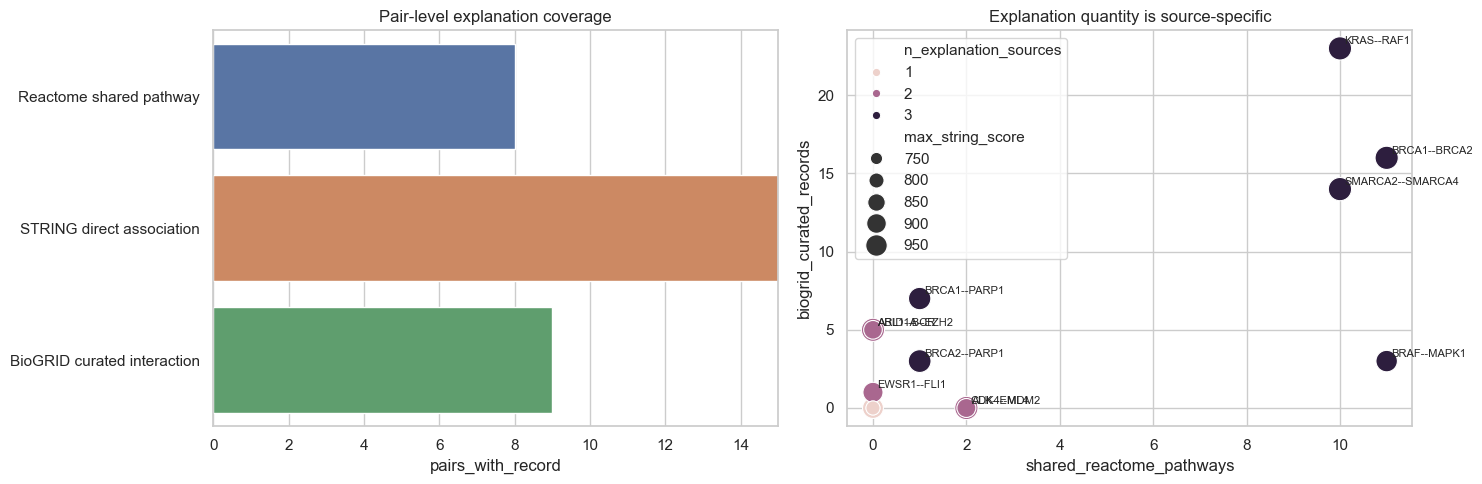

In [3]:
pathway_sizes = reactome.groupby(['pathway_id', 'pathway_name'])['gene_id'].nunique().rename('pathway_genes').reset_index()
reactome_with_size = reactome.merge(pathway_sizes, on=['pathway_id', 'pathway_name'], how='left', validate='many_to_one')
reactome_by_gene = {
    gene_id: group[['pathway_id', 'pathway_name', 'pathway_genes']].drop_duplicates()
    for gene_id, group in reactome_with_size.groupby('gene_id')
}


def pair_explanation(row) -> dict:
    id_a, id_b = sorted([row.gene_a_id, row.gene_b_id])
    string_pair = string_edges.loc[string_edges['gene_a_id'].eq(id_a) & string_edges['gene_b_id'].eq(id_b)]
    biogrid_pair = biogrid_edges.loc[biogrid_edges['gene_a_id'].eq(id_a) & biogrid_edges['gene_b_id'].eq(id_b)]

    pathways_a = reactome_by_gene.get(row.gene_a_id, pd.DataFrame(columns=['pathway_id', 'pathway_name', 'pathway_genes']))
    pathways_b = reactome_by_gene.get(row.gene_b_id, pd.DataFrame(columns=['pathway_id', 'pathway_name', 'pathway_genes']))
    shared_ids = set(pathways_a['pathway_id']) & set(pathways_b['pathway_id'])
    shared = pathways_a.loc[pathways_a['pathway_id'].isin(shared_ids)].sort_values(['pathway_genes', 'pathway_name'])

    sources = []
    if len(shared): sources.append('Reactome')
    if len(string_pair): sources.append('STRING')
    if len(biogrid_pair): sources.append('BioGRID')
    return {
        'pair_id': row.pair_id,
        'shared_reactome_pathways': len(shared),
        'smallest_shared_pathways': ' | '.join(shared['pathway_name'].head(5)),
        'smallest_shared_pathway_gene_counts': ' | '.join(shared['pathway_genes'].head(5).astype(str)),
        'string_direct_edges': len(string_pair),
        'max_string_score': string_pair['combined_score'].max() if len(string_pair) else np.nan,
        'biogrid_experimental_systems': biogrid_pair['experimental_system'].nunique(),
        'biogrid_curated_records': biogrid_pair['n_curated_records'].sum() if len(biogrid_pair) else 0,
        'biogrid_system_examples': ' | '.join(sorted(biogrid_pair['experimental_system'].dropna().unique())[:6]),
        'explanation_sources_found': ' | '.join(sources) if sources else 'no record found in these sources',
    }


pair_explanations = pd.DataFrame([pair_explanation(row) for row in pair_catalog.itertuples(index=False)])
pair_explanations = pair_catalog.merge(pair_explanations, on='pair_id', how='left', validate='one_to_one')
pair_explanations['n_explanation_sources'] = (
    pair_explanations['shared_reactome_pathways'].gt(0).astype(int)
    + pair_explanations['string_direct_edges'].gt(0).astype(int)
    + pair_explanations['biogrid_curated_records'].gt(0).astype(int)
)
display(pair_explanations)

source_pair_counts = pd.DataFrame([
    {'source': 'Reactome shared pathway', 'pairs_with_record': int(pair_explanations['shared_reactome_pathways'].gt(0).sum())},
    {'source': 'STRING direct association', 'pairs_with_record': int(pair_explanations['string_direct_edges'].gt(0).sum())},
    {'source': 'BioGRID curated interaction', 'pairs_with_record': int(pair_explanations['biogrid_curated_records'].gt(0).sum())},
])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=source_pair_counts, x='pairs_with_record', y='source', hue='source', legend=False, ax=axes[0])
axes[0].set_xlim(0, len(pair_catalog)); axes[0].set_title('Pair-level explanation coverage'); axes[0].set_ylabel('')
sns.scatterplot(data=pair_explanations, x='shared_reactome_pathways', y='biogrid_curated_records',
                size='max_string_score', hue='n_explanation_sources', sizes=(50, 280), ax=axes[1])
for row in pair_explanations.itertuples(index=False):
    if row.n_explanation_sources >= 2:
        axes[1].annotate(row.pair_id, (row.shared_reactome_pathways, row.biogrid_curated_records),
                         xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[1].set_title('Explanation quantity is source-specific')
plt.tight_layout(); plt.show()

### What this means for the project

The dashboard can now form statements such as “both genes occur in these named Reactome pathways,” “STRING records a high-confidence functional association,” or “BioGRID contains these experiment types.” A large pathway count is not automatically stronger evidence because Reactome contains nested and broad pathways. Likewise, STRING and BioGRID numbers use different definitions and must not be added together. The explanation is strongest when the exact source and biological meaning remain visible.

## 3. Direct-fusion lineage context

Fusion stability has a special interpretation. A fusion concentrated in one lineage may be biologically meaningful because many driver fusions are disease-specific. We therefore describe recurrence, lineage spread, and the dominant lineage instead of expecting the event to reproduce uniformly across all cancers.

,pair_id,fusion_lineages,dominant_lineage_models,models_with_direct_fusion,dominant_fusion_lineage_pct,dominant_fusion_lineage
0,ABL1--BCR,2,20,24,83.333333,Myeloid
3,EWSR1--FLI1,2,19,20,95.000000,Bone
1,ALK--EML4,4,4,7,57.142857,Lung
2,ERG--TMPRSS2,1,2,2,100.000000,Prostate


,fusion_pair_id,oncotree_lineage,models,junction_reads
1,ABL1--BCR,Myeloid,20,3341
0,ABL1--BCR,Lymphoid,4,427
3,ALK--EML4,Lung,4,194
2,ALK--EML4,Bowel,1,71
4,ALK--EML4,Pancreas,1,31
5,ALK--EML4,Peripheral Nervous System,1,35
6,ERG--TMPRSS2,Prostate,2,413
7,EWSR1--FLI1,Bone,19,3255
8,EWSR1--FLI1,CNS/Brain,1,160


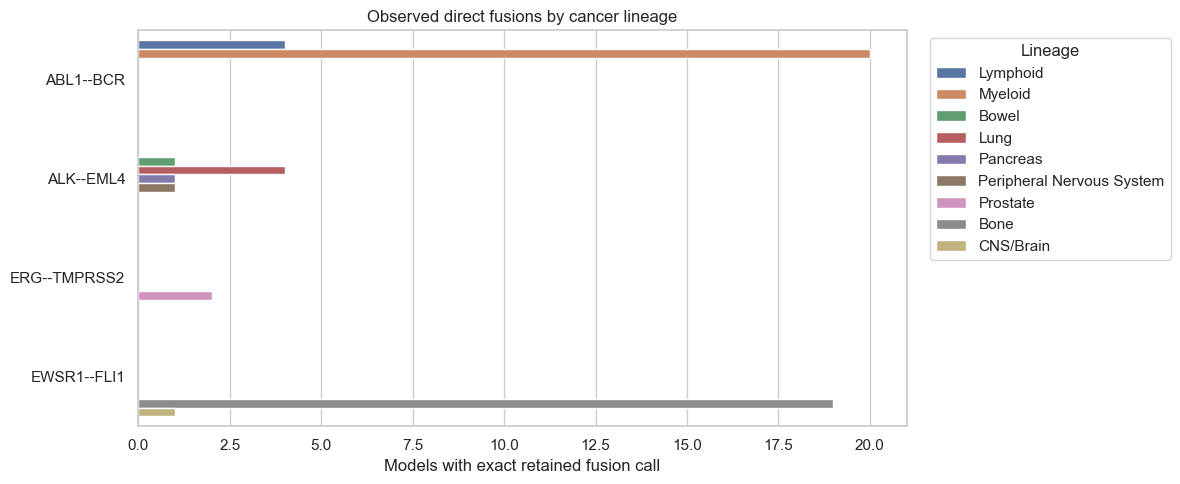

In [4]:
fusion_context = fusion_calls.merge(
    master[['model_id', 'oncotree_lineage', 'cell_line_name']],
    on='model_id', how='left', validate='many_to_one'
)
panel_fusions = fusion_context.loc[fusion_context['fusion_pair_id'].isin(pair_catalog['pair_id'])].copy()
fusion_by_lineage = (
    panel_fusions.groupby(['fusion_pair_id', 'oncotree_lineage'], as_index=False)
    .agg(models=('model_id', 'nunique'), junction_reads=('total_junction_reads', 'sum'))
)
fusion_total = fusion_by_lineage.groupby('fusion_pair_id')['models'].sum().rename('models_with_direct_fusion')
fusion_lineage_summary = fusion_by_lineage.groupby('fusion_pair_id').agg(
    fusion_lineages=('oncotree_lineage', 'nunique'),
    dominant_lineage_models=('models', 'max'),
).join(fusion_total).reset_index().rename(columns={'fusion_pair_id': 'pair_id'})
fusion_lineage_summary['dominant_fusion_lineage_pct'] = 100 * fusion_lineage_summary['dominant_lineage_models'] / fusion_lineage_summary['models_with_direct_fusion']
dominant_names = (
    fusion_by_lineage.sort_values(['fusion_pair_id', 'models'], ascending=[True, False])
    .drop_duplicates('fusion_pair_id')[['fusion_pair_id', 'oncotree_lineage']]
    .rename(columns={'fusion_pair_id': 'pair_id', 'oncotree_lineage': 'dominant_fusion_lineage'})
)
fusion_lineage_summary = fusion_lineage_summary.merge(dominant_names, on='pair_id', how='left', validate='one_to_one')

display(fusion_lineage_summary.sort_values('models_with_direct_fusion', ascending=False))
display(fusion_by_lineage.sort_values(['fusion_pair_id', 'models'], ascending=[True, False]))

plt.figure(figsize=(12, 5))
sns.barplot(data=fusion_by_lineage, x='models', y='fusion_pair_id', hue='oncotree_lineage')
plt.title('Observed direct fusions by cancer lineage')
plt.xlabel('Models with exact retained fusion call'); plt.ylabel('')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Lineage')
plt.tight_layout(); plt.show()

### What this means for the project

The fusion route should answer “where was the exact transcript observed?” rather than “does every lineage reproduce it?” For example, a blood-cancer fusion concentrated in lymphoid or myeloid models is biologically coherent, not automatically unstable. The important checks are exact pair identity, technical read support, recurrence within the relevant disease context, and later functional annotation such as reading frame or retained domains when those data become available.

## 4. Leave-one-lineage-out CRISPR codependency EDA

For each pair, we calculate the lineage-adjusted Spearman correlation and then repeat the calculation while removing one eligible lineage at a time. If the correlation changes sharply after one lineage is removed, the association may be dominated by that disease context. This is a sensitivity analysis; no outcome labels are used.

,pair_id,held_out_runs,median_held_out_rho,minimum_held_out_rho,maximum_held_out_rho,maximum_absolute_change,direction_retained_pct,baseline_models,baseline_adjusted_rho
3,BRAF--MAPK1,22,0.419617,0.374349,0.432993,0.045352,100.000000,1143,0.419701
11,KRAS--RAF1,22,0.300963,0.263809,0.317016,0.035709,100.000000,1143,0.299518
4,BRCA1--BRCA2,22,0.294010,0.279307,0.304263,0.013462,100.000000,1143,0.292768
7,CDK4--MDM2,22,0.143254,0.127704,0.154674,0.015450,100.000000,1143,0.143154
6,BRCA2--PARP1,22,0.093827,0.081394,0.113165,0.019266,100.000000,1143,0.093899
0,ABL1--BCR,22,0.086887,0.068492,0.102078,0.018110,100.000000,1143,0.086601
9,EWSR1--FLI1,22,0.084243,0.020281,0.101238,0.062204,100.000000,1143,0.082484
5,BRCA1--PARP1,22,0.046657,0.032407,0.062418,0.015714,100.000000,1143,0.048120
8,ERG--TMPRSS2,22,0.036143,0.024236,0.050544,0.013526,100.000000,1143,0.037018
2,ARID1A--EZH2,22,0.001702,-0.014371,0.022559,0.020930,63.636364,1143,0.001629


,pair_id,held_out_lineage,held_out_lineage_models,remaining_models,held_out_adjusted_rho,baseline_adjusted_rho,absolute_change_from_baseline,same_direction_as_baseline
76,EWSR1--FLI1,Bone,46,1097,0.020281,0.082484,0.062204,True
290,BRAF--MAPK1,Skin,74,1069,0.374349,0.419701,0.045352,True
182,KRAS--RAF1,Bowel,63,1080,0.263809,0.299518,0.035709,True
110,SMARCA2--SMARCA4,Lung,126,1017,-0.119572,-0.151957,0.032385,True
90,ARID1A--EZH2,CNS/Brain,90,1053,0.022559,0.001629,0.020930,True
155,BRCA2--PARP1,Lymphoid,93,1050,0.113165,0.093899,0.019266,True
71,EWSR1--FLI1,Esophagus/Stomach,69,1074,0.101238,0.082484,0.018754,True
313,KEAP1--STK11,Esophagus/Stomach,69,1074,-0.072901,-0.054514,0.018387,True
13,ABL1--BCR,Myeloid,42,1101,0.068492,0.086601,0.018110,True
188,KRAS--RAF1,Peripheral Nervous System,44,1099,0.317016,0.299518,0.017498,True


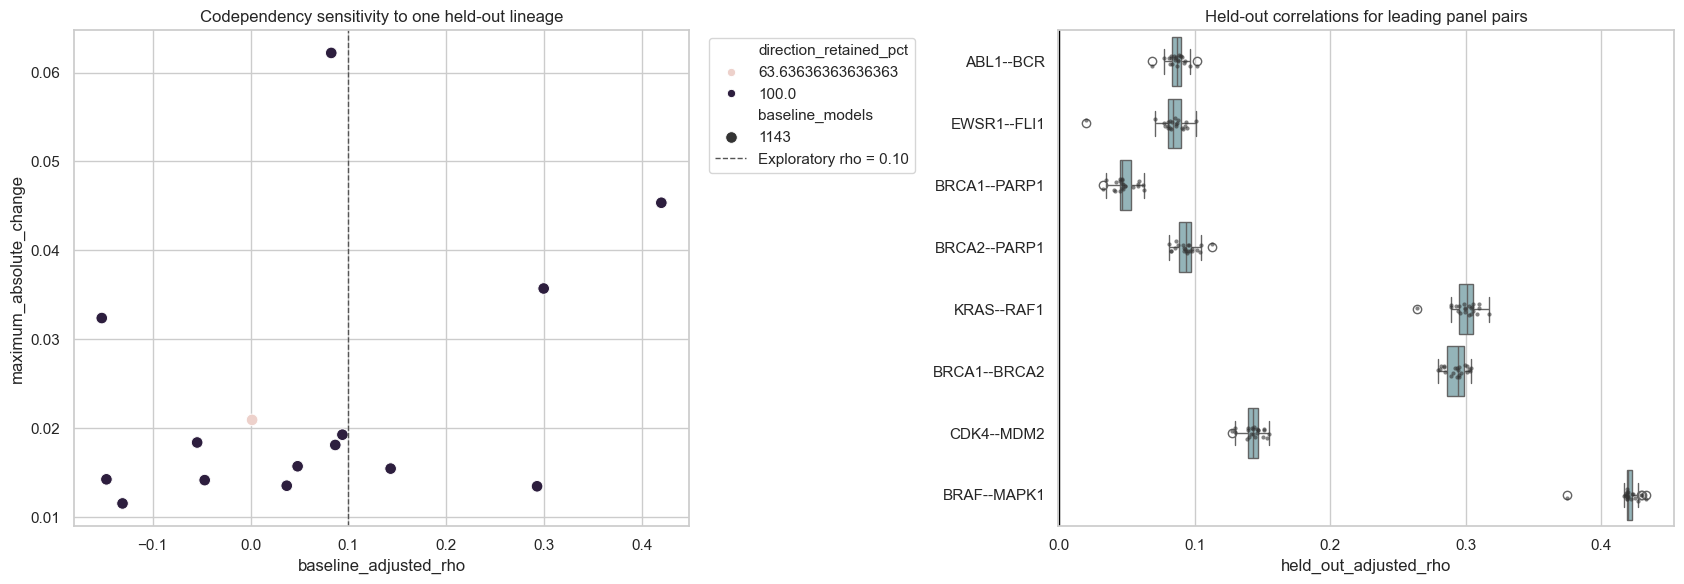

In [5]:
effect_columns = gene_lookup.loc[panel_genes, 'crispr_effect_column'].dropna().to_dict()
effect = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0', *effect_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in effect_columns.items()}}
).set_index('model_id')


def adjusted_codependency(gene_a: str, gene_b: str, excluded_lineage: str | None = None) -> tuple[int, float]:
    frame = effect[[gene_a, gene_b]].copy()
    frame['lineage'] = lineage_lookup.reindex(frame.index)
    frame = frame.dropna()
    if excluded_lineage is not None:
        frame = frame.loc[~frame['lineage'].eq(excluded_lineage)].copy()
    keep = frame.groupby('lineage')[gene_a].transform('size').ge(15)
    frame = frame.loc[keep].copy()
    if len(frame) < 30:
        return len(frame), np.nan
    frame[[gene_a, gene_b]] = frame[[gene_a, gene_b]] - frame.groupby('lineage')[[gene_a, gene_b]].transform('median')
    return len(frame), frame[gene_a].corr(frame[gene_b], method='spearman')


eligible_lineage_counts = lineage_lookup.reindex(effect.index).value_counts()
eligible_lineages = eligible_lineage_counts.loc[eligible_lineage_counts.ge(15)].index.tolist()
codependency_lolo_rows = []
codependency_baseline_rows = []
for pair in pair_catalog.itertuples(index=False):
    baseline_n, baseline_rho = adjusted_codependency(pair.gene_a, pair.gene_b)
    codependency_baseline_rows.append({'pair_id': pair.pair_id, 'baseline_models': baseline_n, 'baseline_adjusted_rho': baseline_rho})
    for lineage in eligible_lineages:
        held_n, held_rho = adjusted_codependency(pair.gene_a, pair.gene_b, lineage)
        codependency_lolo_rows.append({
            'pair_id': pair.pair_id,
            'held_out_lineage': lineage,
            'held_out_lineage_models': int(eligible_lineage_counts[lineage]),
            'remaining_models': held_n,
            'held_out_adjusted_rho': held_rho,
            'baseline_adjusted_rho': baseline_rho,
            'absolute_change_from_baseline': abs(held_rho - baseline_rho),
            'same_direction_as_baseline': np.sign(held_rho) == np.sign(baseline_rho),
        })

codependency_lolo = pd.DataFrame(codependency_lolo_rows)
codependency_baseline = pd.DataFrame(codependency_baseline_rows)
codependency_stability = codependency_lolo.groupby('pair_id').agg(
    held_out_runs=('held_out_adjusted_rho', 'count'),
    median_held_out_rho=('held_out_adjusted_rho', 'median'),
    minimum_held_out_rho=('held_out_adjusted_rho', 'min'),
    maximum_held_out_rho=('held_out_adjusted_rho', 'max'),
    maximum_absolute_change=('absolute_change_from_baseline', 'max'),
    direction_retained_pct=('same_direction_as_baseline', lambda s: 100 * s.mean()),
).reset_index().merge(codependency_baseline, on='pair_id', how='left', validate='one_to_one')

display(codependency_stability.sort_values('baseline_adjusted_rho', ascending=False))
display(codependency_lolo.nlargest(25, 'absolute_change_from_baseline'))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.scatterplot(data=codependency_stability, x='baseline_adjusted_rho', y='maximum_absolute_change',
                hue='direction_retained_pct', size='baseline_models', sizes=(70, 200), ax=axes[0])
axes[0].axvline(0.10, color='#555555', linestyle='--', linewidth=1, label='Exploratory rho = 0.10')
axes[0].set_title('Codependency sensitivity to one held-out lineage')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

top_pairs = codependency_stability.nlargest(8, 'baseline_adjusted_rho')['pair_id']
sns.boxplot(data=codependency_lolo.loc[codependency_lolo['pair_id'].isin(top_pairs)],
            x='held_out_adjusted_rho', y='pair_id', color='#8eb8bf', ax=axes[1])
sns.stripplot(data=codependency_lolo.loc[codependency_lolo['pair_id'].isin(top_pairs)],
              x='held_out_adjusted_rho', y='pair_id', color='#333333', size=3, alpha=0.6, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1); axes[1].set_title('Held-out correlations for leading panel pairs')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

### What this means for the project

A codependency relationship is more convincing when its direction and approximate size remain similar after different lineages are removed. A large change identifies a lineage that deserves separate biological investigation; it does not automatically invalidate the pair. Near-zero baseline correlations can change sign easily, so sign-retention percentages are only informative when read beside the continuous baseline effect size and exact remaining-model counts.

## 5. Leave-one-lineage-out conditional-dependency EDA

We now examine a small, predefined set of directional hypotheses from the previous notebook. Mutation and copy-number loss remain separate context types. The analysis removes one lineage at a time, rebuilds the lineage-adjusted comparison, and records whether the dependency shift keeps the same direction.

,pair_id,directional_pair_id,context_type,evaluable_held_out_runs,median_held_out_shift,minimum_held_out_shift,maximum_held_out_shift,maximum_absolute_change,direction_retained_pct,baseline_context_models,baseline_reference_models,baseline_dependency_shift
0,ARID1A--EZH2,ARID1A -> EZH2,Damaging mutation,22,0.033932,0.020045,0.047349,0.013688,100.0,116,1027,0.033661
1,BRCA1--PARP1,BRCA1 -> PARP1,Damaging mutation,22,0.083418,0.072333,0.093991,0.011085,100.0,21,1122,0.083418
2,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,22,0.045164,0.041040,0.061646,0.016482,100.0,34,1109,0.045164
3,KRAS--RAF1,KRAS -> RAF1,Damaging mutation,22,0.101167,0.091078,0.163772,0.060069,100.0,173,970,0.103703
4,MAT2A--MTAP,MTAP -> MAT2A,Copy-number loss,22,0.054054,0.022942,0.061916,0.031111,100.0,297,478,0.054054
5,MTAP--PRMT5,MTAP -> PRMT5,Copy-number loss,22,0.065917,0.060543,0.076166,0.010773,100.0,297,478,0.065392
6,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,22,0.098731,0.073619,0.141390,0.042806,100.0,61,1082,0.098584


,pair_id,directional_pair_id,context_type,held_out_lineage,held_out_context_models,held_out_reference_models,held_out_dependency_shift,baseline_dependency_shift,absolute_change_from_baseline,same_direction_as_baseline
88,KRAS--RAF1,KRAS -> RAF1,Damaging mutation,Lung,135,882,0.163772,0.103703,0.060069,True
29,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,Ovary/Fallopian Tube,53,1031,0.141390,0.098584,0.042806,True
97,KRAS--RAF1,KRAS -> RAF1,Damaging mutation,Pancreas,129,967,0.141974,0.103703,0.038271,True
34,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,Peripheral Nervous System,57,1042,0.136503,0.098584,0.037920,True
146,MAT2A--MTAP,MTAP -> MAT2A,Copy-number loss,Biliary Tract,289,464,0.022942,0.054054,0.031111,True
22,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,Lung,35,982,0.073619,0.098584,0.024965,True
42,SMARCA2--SMARCA4,SMARCA4 -> SMARCA2,Damaging mutation,Cervix,58,1067,0.120474,0.098584,0.021891,True
150,MAT2A--MTAP,MTAP -> MAT2A,Copy-number loss,Liver,290,466,0.033790,0.054054,0.020264,True
139,MAT2A--MTAP,MTAP -> MAT2A,Copy-number loss,Ovary/Fallopian Tube,284,457,0.034417,0.054054,0.019637,True
72,BRCA2--PARP1,BRCA2 -> PARP1,Damaging mutation,Bowel,23,1057,0.061646,0.045164,0.016482,True


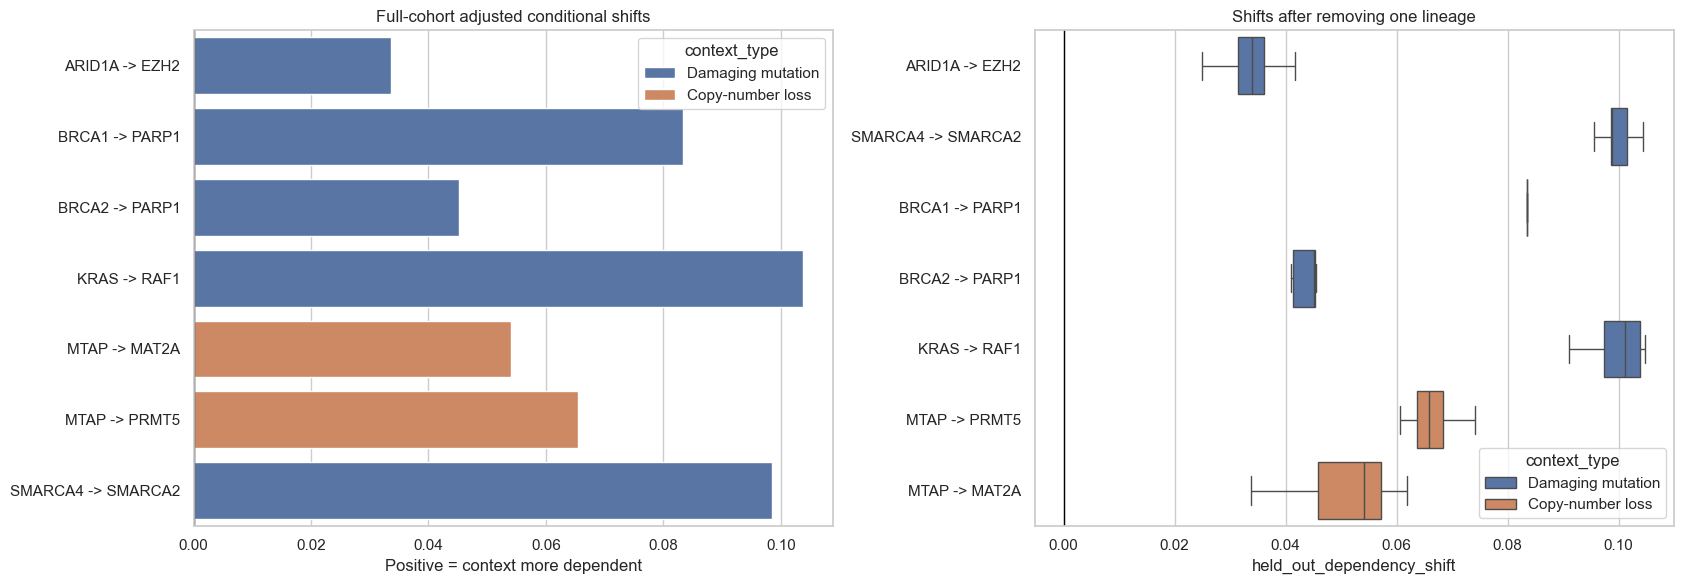

In [6]:
conditional_specs = pd.DataFrame([
    {'context_gene': 'ARID1A', 'target_gene': 'EZH2', 'context_type': 'Damaging mutation'},
    {'context_gene': 'SMARCA4', 'target_gene': 'SMARCA2', 'context_type': 'Damaging mutation'},
    {'context_gene': 'BRCA1', 'target_gene': 'PARP1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'BRCA2', 'target_gene': 'PARP1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'KRAS', 'target_gene': 'RAF1', 'context_type': 'Damaging mutation'},
    {'context_gene': 'MTAP', 'target_gene': 'PRMT5', 'context_type': 'Copy-number loss'},
    {'context_gene': 'MTAP', 'target_gene': 'MAT2A', 'context_type': 'Copy-number loss'},
])
conditional_specs['directional_pair_id'] = conditional_specs['context_gene'] + ' -> ' + conditional_specs['target_gene']
conditional_specs['pair_id'] = [canonical_pair(a, b) for a, b in conditional_specs[['context_gene', 'target_gene']].itertuples(index=False, name=None)]

mutations['damaging_or_driver'] = (
    mutations['has_likely_lof'].eq(1)
    | mutations['highest_vep_impact'].eq('HIGH')
    | mutations[['has_hotspot', 'has_oncogene_high_impact', 'has_tumor_suppressor_high_impact']].eq(1).any(axis=1)
)
copy_context_genes = sorted(conditional_specs.loc[conditional_specs['context_type'].eq('Copy-number loss'), 'context_gene'].unique())
copy_columns = gene_lookup.loc[copy_context_genes, 'copy_number_column'].dropna().to_dict()
copy_number = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0', *copy_columns.values()]).rename(
    columns={'Unnamed: 0': 'model_id', **{v: k for k, v in copy_columns.items()}}
).set_index('model_id')

crispr_ids = set(effect.index)
mutation_universe = crispr_ids & set(master.loc[master['has_mutation_assay'].eq(1), 'model_id'])
copy_universe = crispr_ids & set(master.loc[master['has_absolute_copy_number'].eq(1), 'model_id']) & set(copy_number.index)


def adjusted_dependency_shift(target_gene: str, context_ids: set, reference_ids: set, allowed_ids: set,
                              excluded_lineage: str | None = None) -> dict:
    selected_context = sorted(set(context_ids) & set(allowed_ids) & set(effect.index))
    selected_reference = sorted(set(reference_ids) & set(allowed_ids) & set(effect.index))
    selected = selected_context + selected_reference
    frame = pd.DataFrame({
        'gene_effect': effect.loc[selected, target_gene],
        'lineage': lineage_lookup.reindex(selected),
        'group': ['Context'] * len(selected_context) + ['Reference'] * len(selected_reference),
    }).dropna()
    if excluded_lineage is not None:
        frame = frame.loc[~frame['lineage'].eq(excluded_lineage)].copy()
    keep = frame.groupby('lineage')['gene_effect'].transform('size').ge(15)
    frame = frame.loc[keep].copy()
    frame['residual'] = frame['gene_effect'] - frame.groupby('lineage')['gene_effect'].transform('median')
    context_values = frame.loc[frame['group'].eq('Context'), 'residual']
    reference_values = frame.loc[frame['group'].eq('Reference'), 'residual']
    usable = len(context_values) >= 10 and len(reference_values) >= 10
    return {
        'context_models': len(context_values),
        'reference_models': len(reference_values),
        'dependency_shift': reference_values.median() - context_values.median() if usable else np.nan,
    }


conditional_lolo_rows = []
conditional_baseline_rows = []
conditional_masks = {}
for spec in conditional_specs.itertuples(index=False):
    if spec.context_type == 'Damaging mutation':
        events = mutations.loc[mutations['hugo_symbol'].eq(spec.context_gene) & mutations['damaging_or_driver']]
        context_ids = set(events['model_id']) & mutation_universe
        reference_ids = mutation_universe - context_ids
        allowed_ids = mutation_universe
    else:
        values = copy_number.loc[sorted(copy_universe), spec.context_gene].dropna()
        context_ids = set(values.index[values.le(1)])
        reference_ids = set(values.index[values.gt(1) & values.lt(4)])
        allowed_ids = copy_universe
    conditional_masks[spec.directional_pair_id] = (context_ids, reference_ids, allowed_ids)
    baseline = adjusted_dependency_shift(spec.target_gene, context_ids, reference_ids, allowed_ids)
    conditional_baseline_rows.append({
        'pair_id': spec.pair_id, 'directional_pair_id': spec.directional_pair_id,
        'context_type': spec.context_type,
        'baseline_context_models': baseline['context_models'],
        'baseline_reference_models': baseline['reference_models'],
        'baseline_dependency_shift': baseline['dependency_shift'],
    })
    for lineage in eligible_lineages:
        held = adjusted_dependency_shift(spec.target_gene, context_ids, reference_ids, allowed_ids, lineage)
        conditional_lolo_rows.append({
            'pair_id': spec.pair_id, 'directional_pair_id': spec.directional_pair_id,
            'context_type': spec.context_type, 'held_out_lineage': lineage,
            'held_out_context_models': held['context_models'],
            'held_out_reference_models': held['reference_models'],
            'held_out_dependency_shift': held['dependency_shift'],
            'baseline_dependency_shift': baseline['dependency_shift'],
            'absolute_change_from_baseline': abs(held['dependency_shift'] - baseline['dependency_shift']) if pd.notna(held['dependency_shift']) and pd.notna(baseline['dependency_shift']) else np.nan,
            'same_direction_as_baseline': np.sign(held['dependency_shift']) == np.sign(baseline['dependency_shift']) if pd.notna(held['dependency_shift']) and pd.notna(baseline['dependency_shift']) else np.nan,
        })

conditional_lolo = pd.DataFrame(conditional_lolo_rows)
conditional_baseline = pd.DataFrame(conditional_baseline_rows)
conditional_stability = conditional_lolo.groupby(['pair_id', 'directional_pair_id', 'context_type']).agg(
    evaluable_held_out_runs=('held_out_dependency_shift', 'count'),
    median_held_out_shift=('held_out_dependency_shift', 'median'),
    minimum_held_out_shift=('held_out_dependency_shift', 'min'),
    maximum_held_out_shift=('held_out_dependency_shift', 'max'),
    maximum_absolute_change=('absolute_change_from_baseline', 'max'),
    direction_retained_pct=('same_direction_as_baseline', lambda s: 100 * pd.to_numeric(s, errors='coerce').mean()),
).reset_index().merge(
    conditional_baseline,
    on=['pair_id', 'directional_pair_id', 'context_type'], how='left', validate='one_to_one'
)

display(conditional_stability)
display(conditional_lolo.nlargest(25, 'absolute_change_from_baseline'))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=conditional_stability, x='baseline_dependency_shift', y='directional_pair_id',
            hue='context_type', dodge=False, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1); axes[0].set_title('Full-cohort adjusted conditional shifts')
axes[0].set_xlabel('Positive = context more dependent'); axes[0].set_ylabel('')
sns.boxplot(data=conditional_lolo, x='held_out_dependency_shift', y='directional_pair_id',
            hue='context_type', dodge=False, showfliers=False, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1); axes[1].set_title('Shifts after removing one lineage')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

### What this means for the project

This analysis shows whether a proposed vulnerability is broadly visible or highly dependent on the mix of cancer lineages. A stable positive `ARID1A -> EZH2` shift, for example, would mean that removing any one large lineage does not reverse the overall direction. It still would not prove synthetic lethality: the context is observed molecular data and the outcome is a single-gene knockout, not a controlled double-knockout experiment. Common-essential targets such as PRMT5 or MAT2A also require special caution because broad fitness effects can appear selective after subgrouping.

## 6. Joining measured routes to biological explanations

The table below demonstrates the white-box reporting join. Route measurements and external explanations meet at the canonical pair identity, but their columns remain separate. No pathway count, STRING score, or BioGRID record changes the measured CRISPR or fusion value.

,pair_id,gene_a,gene_b,example_reason,shared_reactome_pathways,smallest_shared_pathways,string_direct_edges,max_string_score,biogrid_experimental_systems,biogrid_curated_records,explanation_sources_found,baseline_adjusted_rho,baseline_models,codependency_maximum_lolo_change,codependency_direction_retained_pct,fusion_lineages,dominant_lineage_models,models_with_direct_fusion,dominant_fusion_lineage_pct,dominant_fusion_lineage
0,ABL1--BCR,ABL1,BCR,Direct fusion example,0,,1,996,2,5,STRING | BioGRID,0.086601,1143,0.018110,100.000000,2,20.0,24,83.333333,Myeloid
1,ALK--EML4,ALK,EML4,Direct fusion example,2,ALK mutants bind TKIs | Signaling by ALK fusio...,1,999,0,0,Reactome | STRING,-0.046801,1143,0.014154,100.000000,4,4.0,7,57.142857,Lung
2,ERG--TMPRSS2,ERG,TMPRSS2,Direct fusion example,0,,1,933,0,0,STRING,0.037018,1143,0.013526,100.000000,1,2.0,2,100.000000,Prostate
3,EWSR1--FLI1,EWSR1,FLI1,Direct fusion example,0,,1,912,1,1,STRING | BioGRID,0.082484,1143,0.062204,100.000000,2,19.0,20,95.000000,Bone
4,ARID1A--EZH2,ARID1A,EZH2,Chromatin conditional-dependency hypothesis,0,,1,877,3,5,STRING | BioGRID,0.001629,1143,0.020930,63.636364,0,NaN,0,NaN,NaN
5,SMARCA2--SMARCA4,SMARCA2,SMARCA4,Paralog conditional-dependency hypothesis,10,Formation of the non-canonical BAF (ncBAF) com...,1,999,6,14,Reactome | STRING | BioGRID,-0.151957,1143,0.032385,100.000000,0,NaN,0,NaN,NaN
6,BRCA1--PARP1,BRCA1,PARP1,DNA-repair conditional-dependency hypothesis,1,SUMOylation of DNA damage response and repair ...,1,974,6,7,Reactome | STRING | BioGRID,0.048120,1143,0.015714,100.000000,0,NaN,0,NaN,NaN
7,BRCA2--PARP1,BRCA2,PARP1,DNA-repair conditional-dependency hypothesis,1,HDR through MMEJ (alt-NHEJ),1,985,2,3,Reactome | STRING | BioGRID,0.093899,1143,0.019266,100.000000,0,NaN,0,NaN,NaN
8,KRAS--RAF1,KRAS,RAF1,Signalling conditional-dependency hypothesis,10,CD209 (DC-SIGN) signaling | RAF activation | S...,1,999,8,23,Reactome | STRING | BioGRID,0.299518,1143,0.035709,100.000000,0,NaN,0,NaN,NaN
9,MTAP--PRMT5,MTAP,PRMT5,Copy-loss conditional-dependency hypothesis,0,,1,771,0,0,STRING,-0.130745,1143,0.011532,100.000000,0,NaN,0,NaN,NaN


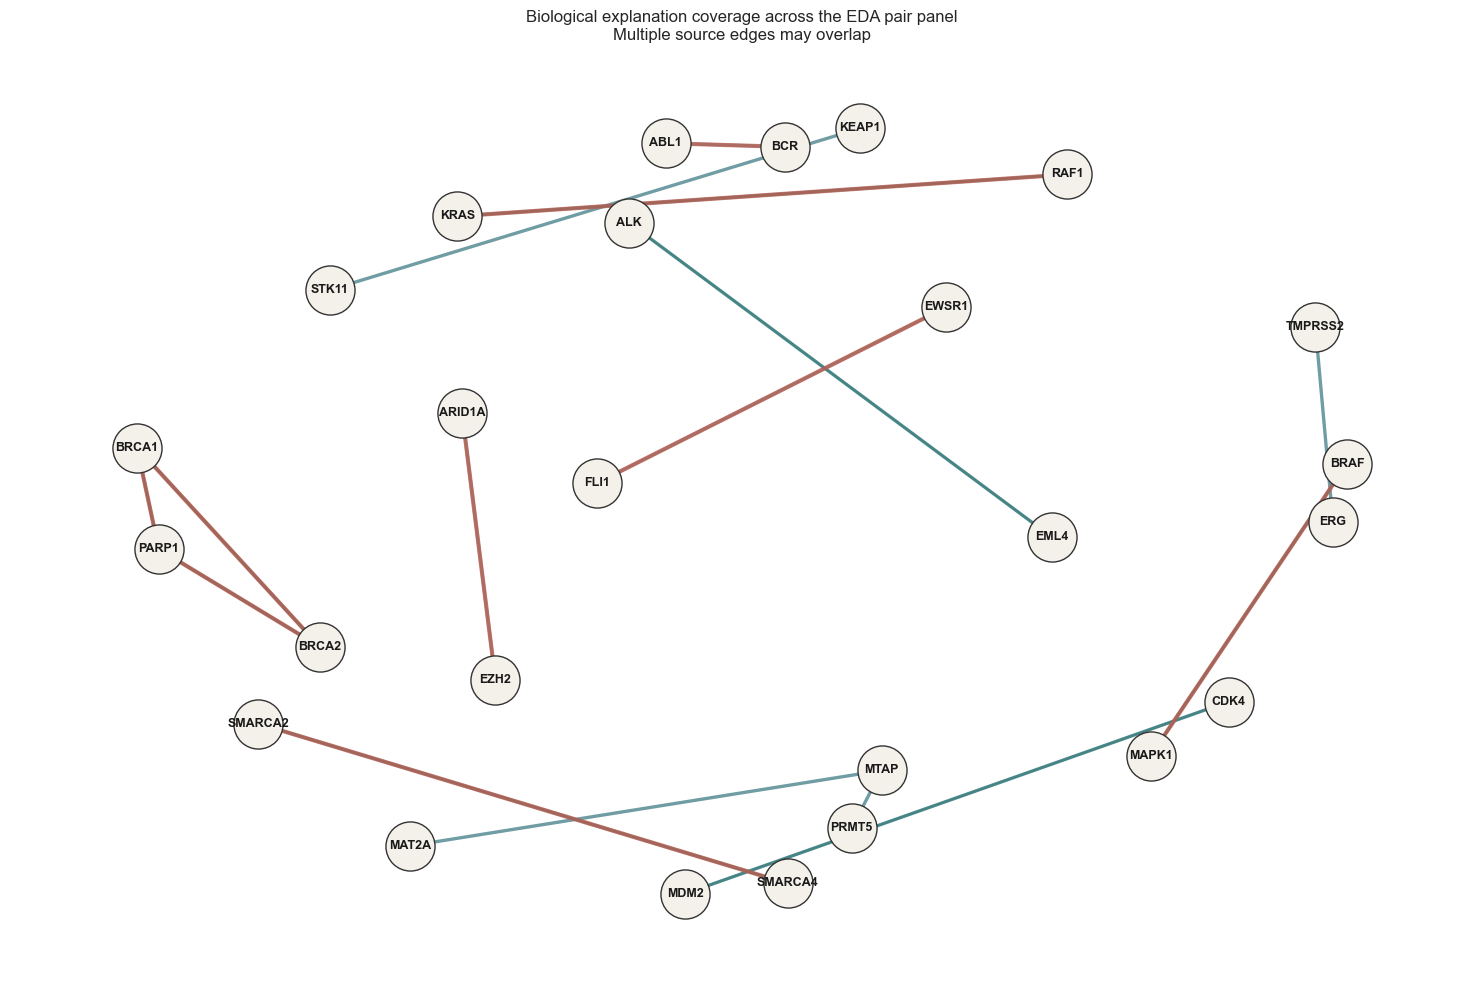

In [7]:
pair_explanation_stability = (
    pair_catalog[['pair_id', 'gene_a', 'gene_b', 'example_reason']]
    .merge(pair_explanations[[
        'pair_id', 'shared_reactome_pathways', 'smallest_shared_pathways',
        'string_direct_edges', 'max_string_score', 'biogrid_experimental_systems',
        'biogrid_curated_records', 'explanation_sources_found'
    ]], on='pair_id', how='left', validate='one_to_one')
    .merge(codependency_stability[[
        'pair_id', 'baseline_adjusted_rho', 'baseline_models',
        'maximum_absolute_change', 'direction_retained_pct'
    ]].rename(columns={
        'maximum_absolute_change': 'codependency_maximum_lolo_change',
        'direction_retained_pct': 'codependency_direction_retained_pct',
    }), on='pair_id', how='left', validate='one_to_one')
    .merge(fusion_lineage_summary, on='pair_id', how='left', validate='one_to_one')
)
pair_explanation_stability['models_with_direct_fusion'] = pair_explanation_stability['models_with_direct_fusion'].fillna(0).astype(int)
pair_explanation_stability['fusion_lineages'] = pair_explanation_stability['fusion_lineages'].fillna(0).astype(int)
display(pair_explanation_stability)

G = nx.Graph()
for row in pair_catalog.itertuples(index=False):
    G.add_edge(row.gene_a, row.gene_b, pair_id=row.pair_id)
pos = nx.spring_layout(G, seed=27, k=1.2)
fig, ax = plt.subplots(figsize=(15, 10))
nx.draw_networkx_nodes(G, pos, node_color='#f4f1ea', edgecolors='#333333', node_size=1250, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
for source, color, width in [
    ('Reactome', '#1b7f5a', 1.8), ('STRING', '#3f7c85', 2.4), ('BioGRID', '#c45b4d', 3.0)
]:
    if source == 'Reactome':
        ids = set(pair_explanations.loc[pair_explanations['shared_reactome_pathways'].gt(0), 'pair_id'])
    elif source == 'STRING':
        ids = set(pair_explanations.loc[pair_explanations['string_direct_edges'].gt(0), 'pair_id'])
    else:
        ids = set(pair_explanations.loc[pair_explanations['biogrid_curated_records'].gt(0), 'pair_id'])
    edge_list = [(r.gene_a, r.gene_b) for r in pair_catalog.itertuples(index=False) if r.pair_id in ids]
    nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color=color, width=width, alpha=0.75, ax=ax)
ax.set_title('Biological explanation coverage across the EDA pair panel\nMultiple source edges may overlap')
ax.axis('off')
plt.tight_layout(); plt.show()

### What this means for the project

This is an explanation layer, not a new prediction layer. A dashboard result can first show what the cell-line data measured, then add known pathway or interaction context underneath. If no external record is found, the correct statement is “no record found in the current database versions,” not “the genes are unrelated.” Keeping source fields separate also lets a reviewer check whether an explanation came from a pathway annotation, a functional association, or a specific experiment.

## 7. External validation target and readiness

Before fitting a final predictor, the project needs an outcome that is independent of the features being tested. The current local biological databases enrich explanations, while the local TCGA table contains clinical context only. Neither is currently a complete answer key for whether two genes form a viable or therapeutically useful relationship.

In [8]:
validation_readiness = pd.DataFrame([
    {
        'route_or_goal': 'Direct fusion validity',
        'preferred_external_target': 'Curated functional or driver-fusion label with cancer type and evidence level',
        'required_grain': 'canonical gene pair + orientation + lineage + functional label',
        'currently_local': False,
        'what_is_local_now': 'Observed DepMap fusion calls and technical support',
        'why_not_an_answer_key': 'An observed transcript does not prove an in-frame functional driver.',
    },
    {
        'route_or_goal': 'CRISPR codependency plausibility',
        'preferred_external_target': 'Held-out curated complex or pathway relationships not used as model features',
        'required_grain': 'undirected gene pair + positive/negative relationship label + source version',
        'currently_local': False,
        'what_is_local_now': 'Reactome, STRING, and BioGRID explanation evidence',
        'why_not_an_answer_key': 'Using the same records as both features and labels would leak the expected answer.',
    },
    {
        'route_or_goal': 'Conditional or synthetic-lethal dependency',
        'preferred_external_target': 'Independent combinatorial CRISPR, isogenic perturbation, or curated synthetic-lethal outcome',
        'required_grain': 'Gene A state + Gene B perturbation + lineage + measured viability effect',
        'currently_local': False,
        'what_is_local_now': 'Observational molecular context plus single-gene CRISPR effect',
        'why_not_an_answer_key': 'Association in single-gene screens is not a controlled gene-pair experiment.',
    },
    {
        'route_or_goal': 'Transfer to human tumours',
        'preferred_external_target': 'TCGA molecular mutation, copy-number, RNA, and subtype data',
        'required_grain': 'patient/sample + molecular feature + tumour type',
        'currently_local': False,
        'what_is_local_now': 'TCGA patient and clinical cohort metadata only',
        'why_not_an_answer_key': 'Clinical metadata alone cannot test whether a molecular pair occurs in tumours.',
    },
])
display(validation_readiness)

validation_target_contract = pd.DataFrame([
    {'field': 'pair_id', 'required': True, 'meaning': 'Canonical undirected pair identity'},
    {'field': 'directional_pair_id', 'required': 'conditional routes', 'meaning': 'Gene A context -> Gene B perturbation'},
    {'field': 'context_definition', 'required': 'conditional routes', 'meaning': 'Exact mutation, loss, gain, or expression rule'},
    {'field': 'cancer_lineage_or_subtype', 'required': True, 'meaning': 'Disease context of the experiment or curation'},
    {'field': 'validation_label', 'required': True, 'meaning': 'Positive, negative, or continuous measured outcome'},
    {'field': 'assay_type', 'required': True, 'meaning': 'Double knockout, isogenic experiment, curated driver status, or other method'},
    {'field': 'evidence_source_and_version', 'required': True, 'meaning': 'Traceable provenance'},
    {'field': 'sample_or_experiment_count', 'required': True, 'meaning': 'Validation denominator'},
    {'field': 'reserved_for_evaluation', 'required': True, 'meaning': 'Must not also be used to create the tested features'},
])
display(validation_target_contract)

local_readiness = pd.DataFrame([
    {'local_resource': 'Reactome', 'ready_for': 'Biological pathway explanation', 'not_ready_for': 'Independent label if pathway features enter the model'},
    {'local_resource': 'STRING', 'ready_for': 'Functional-association explanation', 'not_ready_for': 'Proof of physical binding or synthetic lethality'},
    {'local_resource': 'BioGRID', 'ready_for': 'Experiment-type explanation', 'not_ready_for': 'Automatic positive label without assay review'},
    {'local_resource': 'TCGA clinical', 'ready_for': 'Cohort and tumour-type planning', 'not_ready_for': 'Molecular pair validation'},
])
display(local_readiness)

,route_or_goal,preferred_external_target,required_grain,currently_local,what_is_local_now,why_not_an_answer_key
0,Direct fusion validity,Curated functional or driver-fusion label with...,canonical gene pair + orientation + lineage + ...,False,Observed DepMap fusion calls and technical sup...,An observed transcript does not prove an in-fr...
1,CRISPR codependency plausibility,Held-out curated complex or pathway relationsh...,undirected gene pair + positive/negative relat...,False,"Reactome, STRING, and BioGRID explanation evid...",Using the same records as both features and la...
2,Conditional or synthetic-lethal dependency,"Independent combinatorial CRISPR, isogenic per...",Gene A state + Gene B perturbation + lineage +...,False,Observational molecular context plus single-ge...,Association in single-gene screens is not a co...
3,Transfer to human tumours,"TCGA molecular mutation, copy-number, RNA, and...",patient/sample + molecular feature + tumour type,False,TCGA patient and clinical cohort metadata only,Clinical metadata alone cannot test whether a ...


,field,required,meaning
0,pair_id,True,Canonical undirected pair identity
1,directional_pair_id,conditional routes,Gene A context -> Gene B perturbation
2,context_definition,conditional routes,"Exact mutation, loss, gain, or expression rule"
3,cancer_lineage_or_subtype,True,Disease context of the experiment or curation
4,validation_label,True,"Positive, negative, or continuous measured out..."
5,assay_type,True,"Double knockout, isogenic experiment, curated ..."
6,evidence_source_and_version,True,Traceable provenance
7,sample_or_experiment_count,True,Validation denominator
8,reserved_for_evaluation,True,Must not also be used to create the tested fea...


,local_resource,ready_for,not_ready_for
0,Reactome,Biological pathway explanation,Independent label if pathway features enter th...
1,STRING,Functional-association explanation,Proof of physical binding or synthetic lethality
2,BioGRID,Experiment-type explanation,Automatic positive label without assay review
3,TCGA clinical,Cohort and tumour-type planning,Molecular pair validation


### What this means for the project

The project is ready to explain exploratory relationships, but it is not yet ready to call them correct or calculate a probability. The strongest next data decision is to choose one independent validation target for each route and reserve it from feature engineering. For synthetic lethality, the most direct answer key would be a controlled combinatorial or isogenic perturbation outcome. For tumour relevance, TCGA molecular layers must be added; the current clinical table only helps define cohorts.

## 8. Decisions carried forward

In [9]:
decisions = pd.DataFrame([
    {'decision': 'Explanation sources', 'rule': 'Keep Reactome, STRING, and BioGRID in separate source-labelled fields.'},
    {'decision': 'No-record state', 'rule': 'Report database-version absence as no record found, never biological absence.'},
    {'decision': 'Fusion lineage', 'rule': 'Treat lineage concentration as biological context, not generic instability.'},
    {'decision': 'Codependency stability', 'rule': 'Carry baseline rho, held-out range, maximum change, and exact n together.'},
    {'decision': 'Conditional stability', 'rule': 'Keep direction and context definition; require at least 10 models in both adjusted groups.'},
    {'decision': 'Validation leakage', 'rule': 'A source used to build a feature cannot also serve as the independent answer key for that feature.'},
    {'decision': 'Modelling gate', 'rule': 'Do not fit or calibrate until outcome grain, negatives, lineage split, and source version are fixed.'},
])
display(decisions)

assert pair_catalog['pair_id'].is_unique
assert pair_explanations['pair_id'].is_unique
assert codependency_stability['pair_id'].is_unique
assert set(codependency_lolo['held_out_lineage']) == set(eligible_lineages)
assert conditional_lolo.loc[conditional_lolo['held_out_dependency_shift'].notna(), 'held_out_context_models'].ge(10).all()
assert conditional_lolo.loc[conditional_lolo['held_out_dependency_shift'].notna(), 'held_out_reference_models'].ge(10).all()

print('Validation checks passed.')
print(f'EDA panel pairs: {len(pair_catalog):,}')
print(f'Pairs with at least one biological explanation source: {pair_explanations.n_explanation_sources.gt(0).sum():,}')
print(f'Eligible held-out lineages: {len(eligible_lineages):,}')
print(f'Codependency leave-one-lineage-out runs: {len(codependency_lolo):,}')
print(f'Evaluable conditional leave-one-lineage-out runs: {conditional_lolo.held_out_dependency_shift.notna().sum():,}')

,decision,rule
0,Explanation sources,"Keep Reactome, STRING, and BioGRID in separate..."
1,No-record state,Report database-version absence as no record f...
2,Fusion lineage,Treat lineage concentration as biological cont...
3,Codependency stability,"Carry baseline rho, held-out range, maximum ch..."
4,Conditional stability,Keep direction and context definition; require...
5,Validation leakage,A source used to build a feature cannot also s...
6,Modelling gate,"Do not fit or calibrate until outcome grain, n..."


Validation checks passed.
EDA panel pairs: 15
Pairs with at least one biological explanation source: 15
Eligible held-out lineages: 22
Codependency leave-one-lineage-out runs: 330
Evaluable conditional leave-one-lineage-out runs: 154


### What this means for the project

The EDA has now moved from “is there a relationship?” to “can we explain it, and is it overly dependent on one disease group?” That is the correct stage before modelling. The next task should be a validation-data design decision and data audit, followed by held-out testing only after the outcome definition has been approved.